In [1]:
import os
import sys
os.chdir("../")
sys.path.insert(0, os.path.abspath("."))
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ldc.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

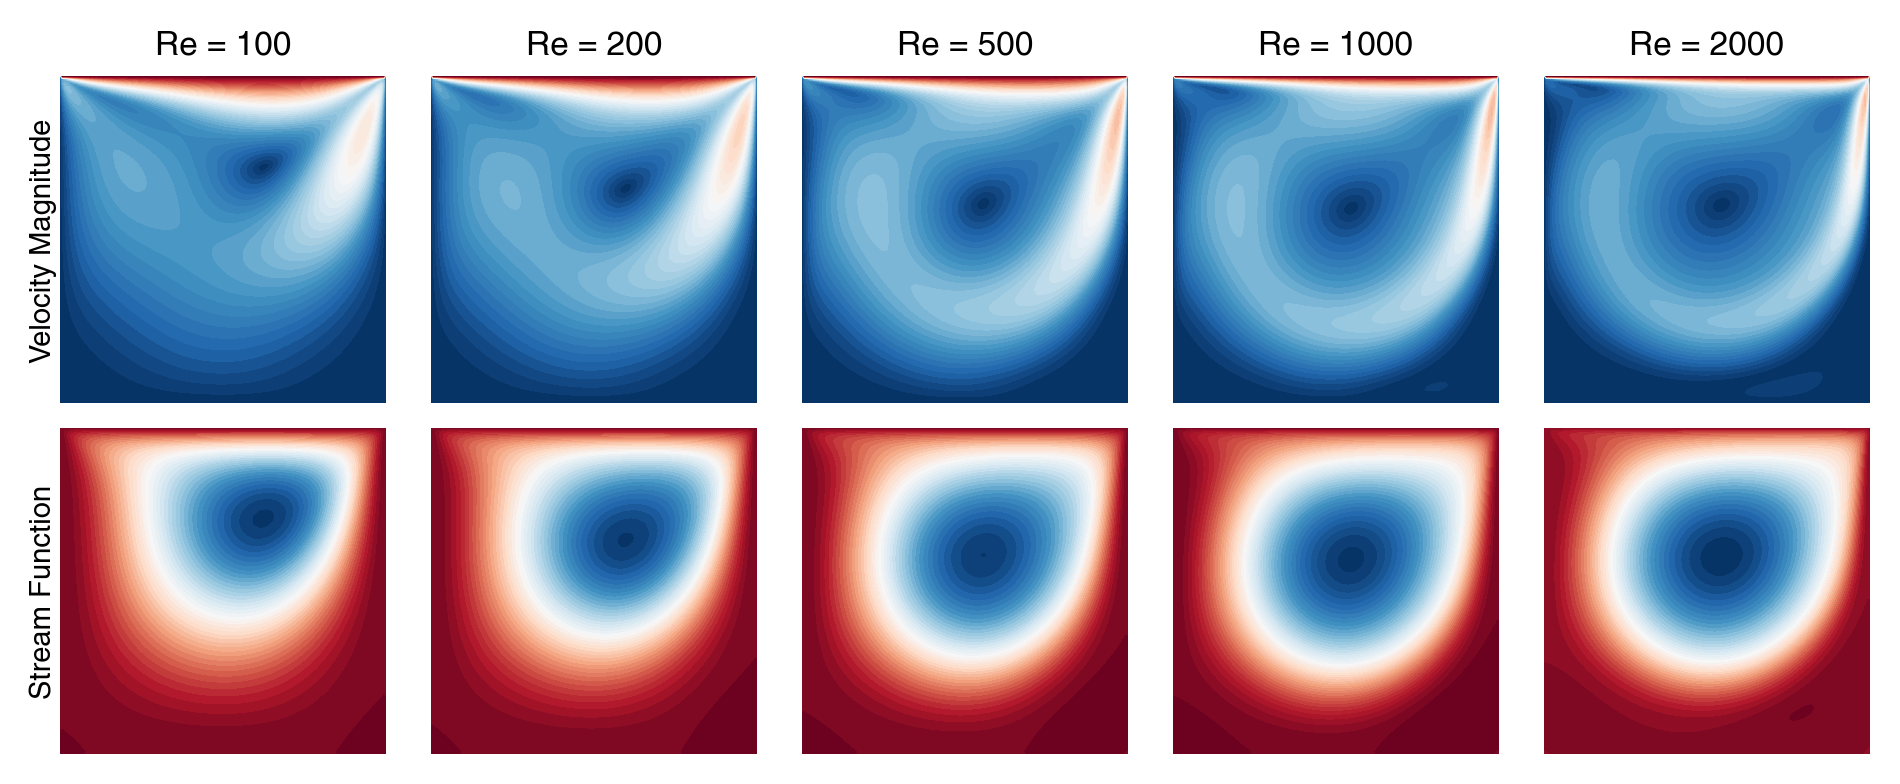

In [6]:
re_vals = [100, 200, 500, 1000, 2000]
data_paths = [f"./data/ldc/flow_fields_Re{re_val}_N128.npz" for re_val in re_vals]
x = jnp.linspace(0, 1, 128)
y = jnp.linspace(0, 1, 128)
X, Y = jnp.meshgrid(x, y, indexing="xy")

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(re_vals),
    figsize=(1.25 * len(re_vals), 1.25*2),
    constrained_layout=True,
)
for idx, (re_val, data_path) in enumerate(zip(re_vals, data_paths)):
    data = jnp.load(data_path)
    u = data["u"]
    v = data["v"]
    speed = jnp.sqrt(u**2 + v**2)
    ax = axes[0, idx]
    ax.contourf(
        X, Y, speed,
        levels=50,
        cmap="RdBu_r",
        vmin=0,
        vmax=1.0,
    )
    ax.set_axis_off()
    ax.text(
        0.5, 1.05,
        f"Re = {re_val}",
        fontsize=8,
        ha="center",
        va="bottom",
        transform=ax.transAxes,
    )
    ax.set_aspect("equal")
    
    ax = axes[1, idx]
    psi = data["psi"]
    ax.contourf(
        X, Y, psi,
        levels=50,
        cmap="RdBu_r",
    )
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    if idx == 0:
        axes[0, idx].text(
            -0.05, 0.5,
            "Velocity Magnitude",
            fontsize=7,
            rotation=90,
            ha="center",
            va="center",
            transform=axes[0, idx].transAxes,
        )
        axes[1, idx].text(
            -0.05, 0.5,
            "Stream Function",
            fontsize=7,
            rotation=90,
            ha="center",
            va="center",
            transform=axes[1, idx].transAxes,
        )